In [51]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [52]:
# Load and view data
df = pd.read_csv("liver_patient_dataset.csv")
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


In [53]:
df.shape

(583, 11)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 50.2+ KB


In [55]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000


### Data Cleaning and Preprocessing

In [56]:
df.isnull().sum()

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Selector     0
dtype: int64

In [57]:
df.duplicated().sum()

13

In [58]:
df.loc[df.duplicated()]

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
19,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.80,Liver Disease
26,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.10,Liver Disease
34,38,Female,2.6,1.2,410,59,57,5.6,3.0,0.80,No Liver Disease
55,42,Male,8.9,4.5,272,31,61,5.8,2.0,0.50,Liver Disease
62,58,Male,1.0,0.5,158,37,43,7.2,3.6,1.00,Liver Disease
106,36,Male,5.3,2.3,145,32,92,5.1,2.6,1.00,No Liver Disease
108,36,Male,0.8,0.2,158,29,39,6.0,2.2,0.50,No Liver Disease
138,18,Male,0.8,0.2,282,72,140,5.5,2.5,0.80,Liver Disease
143,30,Male,1.6,0.4,332,84,139,5.6,2.7,0.90,Liver Disease
158,72,Male,0.7,0.1,196,20,35,5.8,2.0,0.50,Liver Disease


In [59]:
# Encoding 'gender' and target columns

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Selector'] = df['Selector'].map({'Liver Disease': 1, 'No Liver Disease': 0})

### EDA

In [60]:
df['Selector'].value_counts(normalize=True) * 100

1    71.35506
0    28.64494
Name: Selector, dtype: float64

Text(0.5, 1.0, 'Target Distribution')

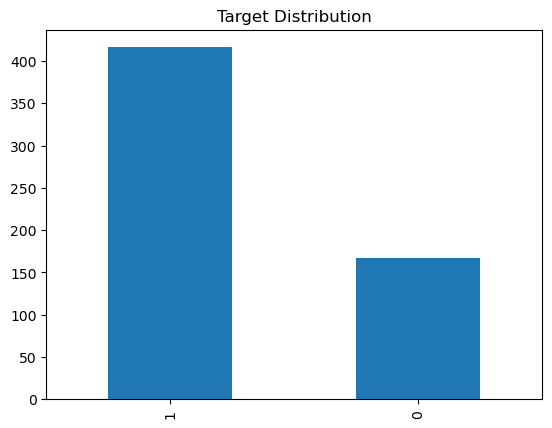

In [61]:
# Target distribution
df['Selector'].value_counts().plot(kind='bar')
plt.title("Target Distribution")

The dataset is imbalanced, with approximately 72% of samples belonging to the Liver Disease class and 28% to the No Liver Disease class. This imbalance can bias machine learning models toward the majority class, leading to misleading accuracy. Therefore, appropriate techniques such as resampling (e.g., SMOTE) and evaluation metrics like precision, recall, and F1-score are necessary.

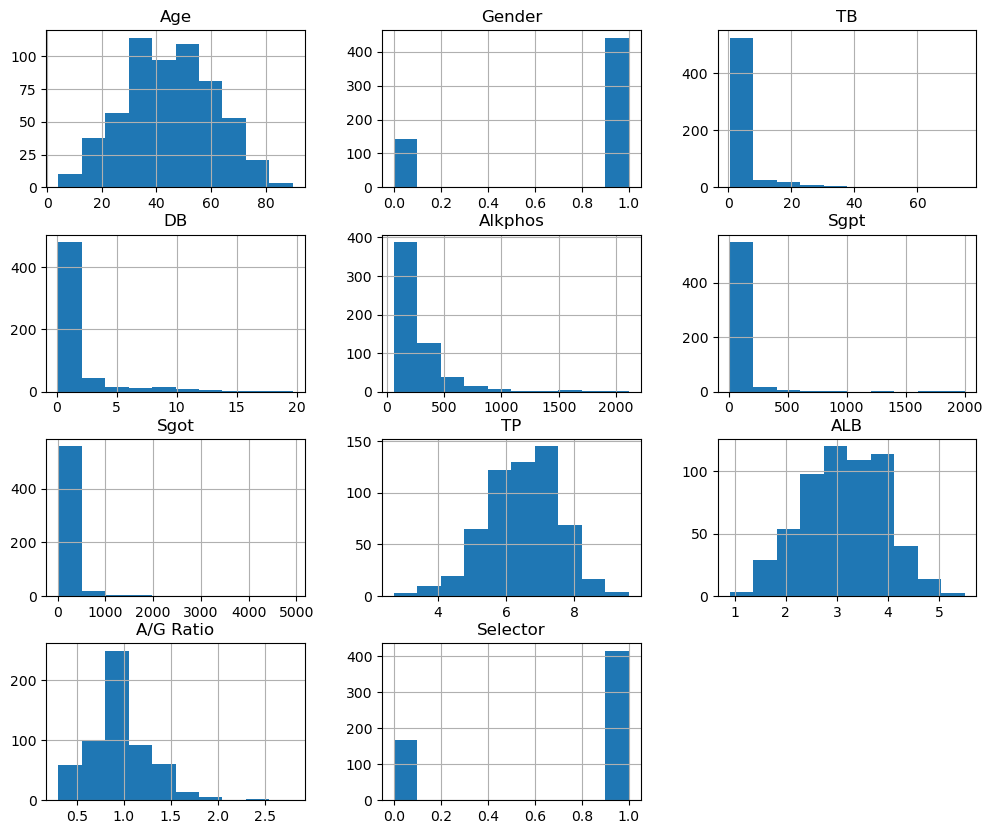

In [62]:
df.hist(figsize=(12,10))
plt.show()

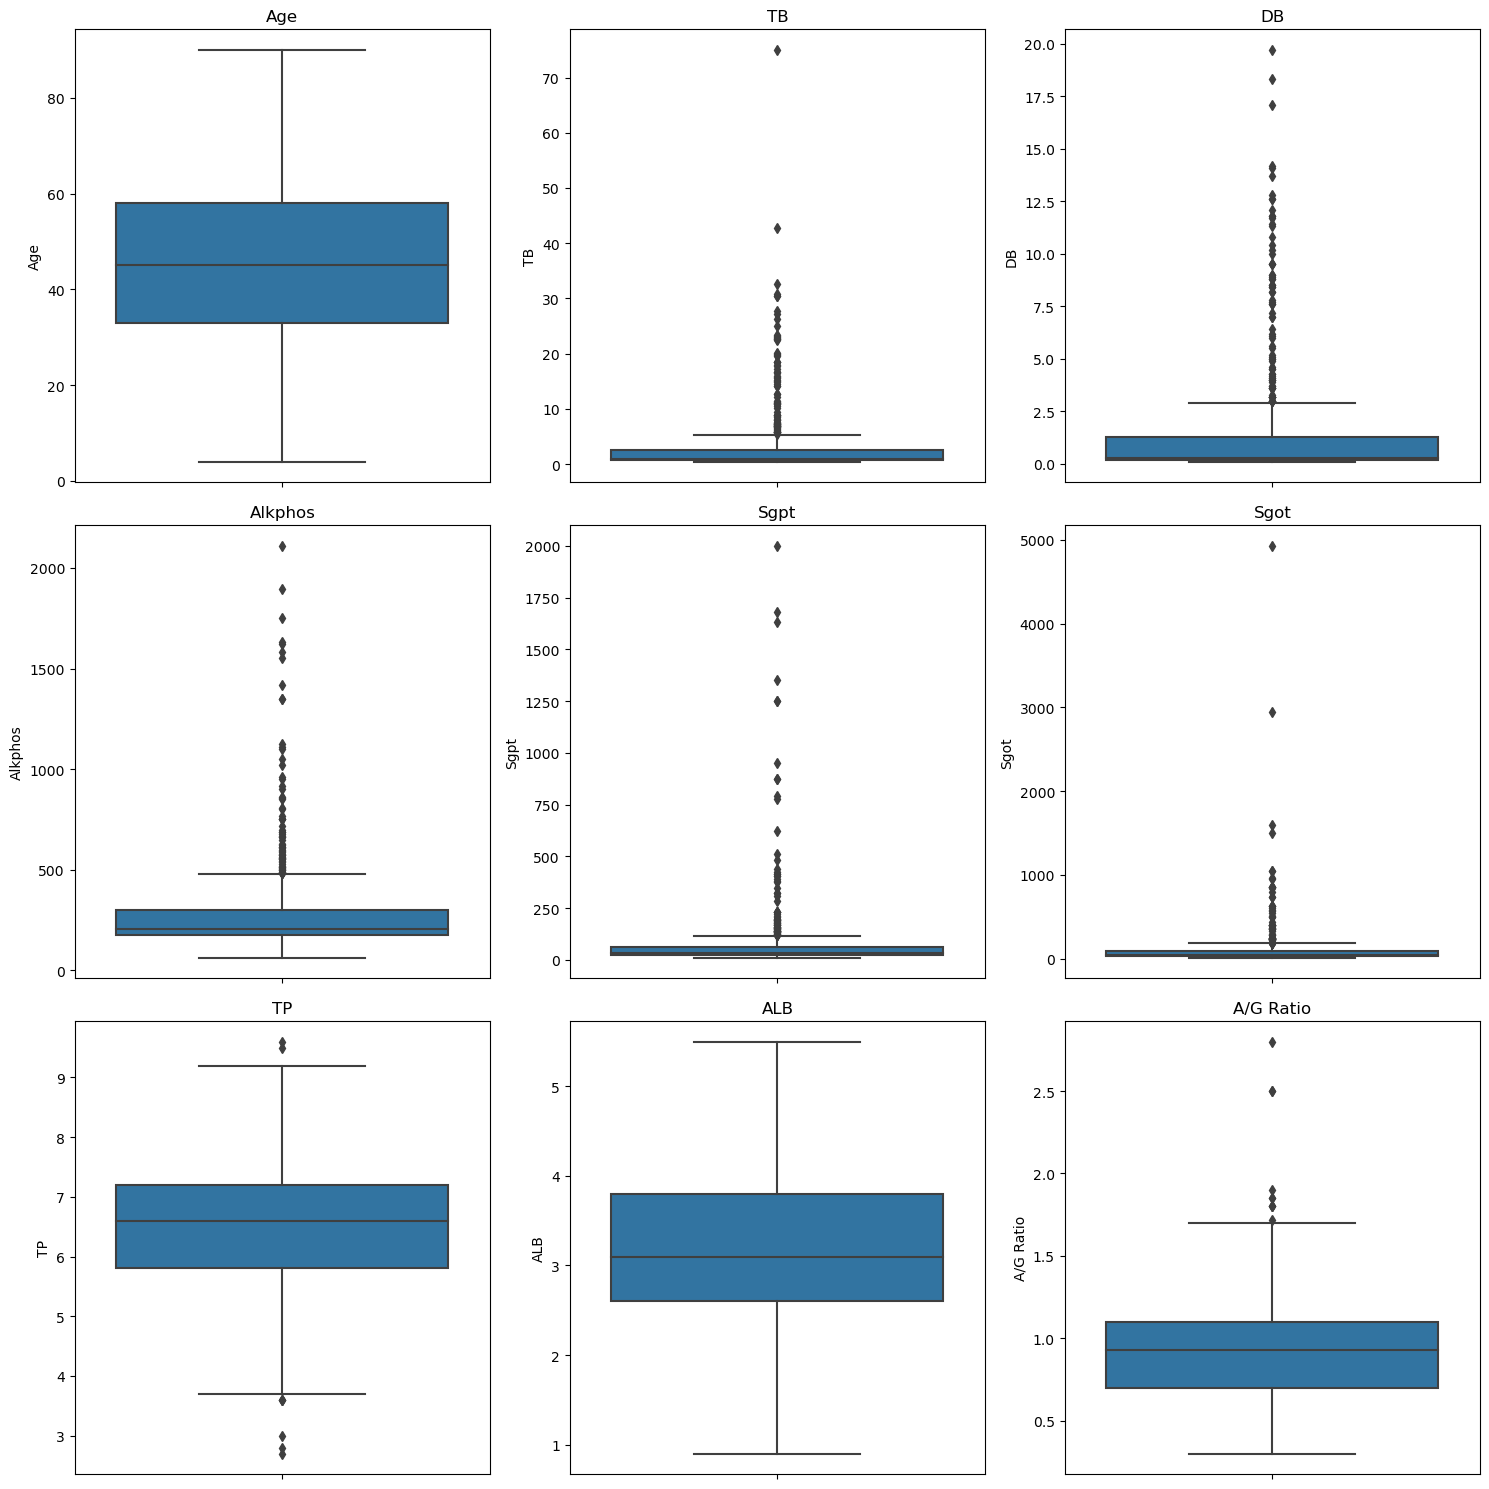

In [63]:
exclude_cols = ['Gender', 'Selector']
cols = [col for col in df.columns if col not in exclude_cols]

# Define subplot grid
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

# Plot each feature
for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Feature Engineering

In [64]:
# Log Transforming skewed data

skewed_cols = ['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot']

for col in skewed_cols:
    df[col] = np.log1p(df[col])  # log(1 + x)

In [65]:
X = df.drop('Selector', axis=1)
y = df['Selector']

In [66]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y)

In [67]:
# Handling Imbalance

from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_train, y_train = smote.fit_resample(x_train, y_train)

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Model Training

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [70]:
lr_model = LogisticRegression(class_weight='balanced')
lr_model.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [71]:
knn_model = KNeighborsClassifier(n_neighbors= 5)
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [72]:
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)

GaussianNB()

In [73]:
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)

DecisionTreeClassifier()

In [74]:
svm_model = SVC(kernel="rbf")
svm_model.fit(x_train_scaled, y_train)

SVC()

### Model Evaluation

In [75]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


models = {
    "Logistic Regression": (lr_model, x_test_scaled),
    "KNN": (knn_model, x_test_scaled),
    "SVM": (svm_model, x_test_scaled),
    "Naive Bayes": (nb_model, x_test),
    "Decision Tree": (dt_model, x_test)
}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

--- Logistic Regression ---
Accuracy: 0.6986301369863014
[[31  6]
 [38 71]]
              precision    recall  f1-score   support

           0       0.45      0.84      0.58        37
           1       0.92      0.65      0.76       109

    accuracy                           0.70       146
   macro avg       0.69      0.74      0.67       146
weighted avg       0.80      0.70      0.72       146

--- KNN ---
Accuracy: 0.6301369863013698
[[22 15]
 [39 70]]
              precision    recall  f1-score   support

           0       0.36      0.59      0.45        37
           1       0.82      0.64      0.72       109

    accuracy                           0.63       146
   macro avg       0.59      0.62      0.59       146
weighted avg       0.71      0.63      0.65       146

--- SVM ---
Accuracy: 0.7191780821917808
[[31  6]
 [35 74]]
              precision    recall  f1-score   support

           0       0.47      0.84      0.60        37
           1       0.93      0.68      0.

Clearly, logistic regression model performs the best. But, it still has lower recall value leading to false alarms

In [76]:
y_prob = lr_model.predict_proba(x_test_scaled)[:,1]

y_pred = (y_prob > 0.4).astype(int)  # instead of 0.5

In [78]:
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n\n')
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.7534246575342466


[[23 14]
 [22 87]]


In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.62      0.56        37
           1       0.86      0.80      0.83       109

    accuracy                           0.75       146
   macro avg       0.69      0.71      0.69       146
weighted avg       0.77      0.75      0.76       146



The decision threshold of the Logistic Regression model was adjusted from 0.5 to 0.4 to improve recall for the liver disease class. This resulted in an increase in recall from 0.67 to 0.80, significantly reducing false negatives. Although this led to a slight decrease in precision for the non-disease class, it is acceptable in a medical context where early detection is prioritized over false alarms.

### Saving the best model

In [81]:
import joblib

# Save model
joblib.dump(lr_model, "lr_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

joblib.dump(X.columns.to_list(), "columns.pkl")


['columns.pkl']